# LCS drift detection V2
Changes to this script:
- Change normalize all rows to the same scale. The importance is the drift of the values. This way we can concatenate the analytes of a job in alphabetical order. Create a longer time series of one job. The drift of one specific analyte doesnt currently have an issue when one specific 

In [53]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

In [54]:
df = pd.read_csv("Data/raw/ResultSet.csv")
df.columns = [c.strip().upper() for c in df.columns]

for col in ["NUMERIC_FINAL_VALUE", "INTERNAL_TARGET_VALUE",
            "INTERNAL_MAX_WARNING_VALUE", "INTERNAL_MIN_WARNING_VALUE",
            "INTERNAL_MAX_VALUE", "INTERNAL_MIN_VALUE"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")

print(f"Loaded {len(df):,} rows")
print("Available STD_LOT_CODEs:")
print(df[df["ANALYTICAL_TYPE"] == "Standard"]["STD_LOT_CODE"].value_counts().to_string())

Loaded 99,999 rows
Available STD_LOT_CODEs:
STD_LOT_CODE
Sample        6958
OREAS_905     5661
OREAS_62F     5551
OREAS_501C    5410
OREAS_503C    4305
OREAS_624     4299
OREAS_522     1122
OREAS_139     1013
OREAS_908      735
OREAS_524      519
OREAS_503D     225
OREAS_351      205
OREAS_20A      164
OREAS_98       157
OREAS_623      136
OREAS_621       61
OREAS_505       58
OREAS_520       26
OREAS_136       25
OREAS_38        21
OREAS_45F       10
OREAS_45H       10
OREAS_622       10
OREAS_605        6


In [55]:
# ── INPUT ────────────────────────────────────────────────────────────────────
STD_LOT_CODE = "OREAS_905"   # change to any STD_LOT_CODE from the list above
JOB_CODE = 'TSV_LB0005186144'
df[(df["ANALYTICAL_TYPE"] == "Standard") & (df["STD_LOT_CODE"] == STD_LOT_CODE) & (df["JOB_CODE"] == JOB_CODE)]["JOB_CODE"].value_counts()


JOB_CODE
TSV_LB0005186144    172
Name: count, dtype: int64

# Normalize all rows of df_standard

In [56]:
df_standard = df[df["ANALYTICAL_TYPE"] == "Standard"]
df_standard[
    [
        "JOB_CODE",
        "STD_CODE",
        "ANALYTE_CODE",
        "STANDARD_STATUS",
        "NUMERIC_FINAL_VALUE",
        "INTERNAL_MIN_VALUE",
        "INTERNAL_TARGET_VALUE",
        "INTERNAL_MAX_VALUE",
        "INTERNAL_MAX_WARNING_VALUE",
    ]
].head(5)

,JOB_CODE,STD_CODE,ANALYTE_CODE,STANDARD_STATUS,NUMERIC_FINAL_VALUE,INTERNAL_MIN_VALUE,INTERNAL_TARGET_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MAX_WARNING_VALUE
0,TSV_LB0016663011,OREAS_905,PB,UpperFailure,35.927171,26.11056,30.40,34.68944,33.12080
1,TSV_LB0016663011,OREAS_905,PB,UpperFailure,55.639610,26.11056,30.40,34.68944,33.12080
4,TSV_LB0016663011,OREAS_905,NI,UpperWarning,11.742601,7.33626,9.54,11.74374,10.93761
5,TSV_LB0016663011,OREAS_905,NI,UpperFailure,12.236060,7.33626,9.54,11.74374,10.93761
7,TSV_LB0016663011,OREAS_905,CU,Pass,1501.882410,1379.70000,1533.00,1686.30000,1630.19220


# transform values for warning and failure drift detection

In [57]:
# Create a transformed copy of df_standard
trans_warning_bound = (
	df_standard["INTERNAL_MAX_WARNING_VALUE"]
	- df_standard["INTERNAL_TARGET_VALUE"]
)

df_standard["Normalized_Warning"] = (
	df_standard["NUMERIC_FINAL_VALUE"] - df_standard["INTERNAL_TARGET_VALUE"]
).div(trans_warning_bound).replace([np.inf, -np.inf], np.nan)

trans_failure_bound = (
	df_standard["INTERNAL_MAX_VALUE"]
	- df_standard["INTERNAL_TARGET_VALUE"]
)

df_standard["Normalized_Failure"] = (
	df_standard["NUMERIC_FINAL_VALUE"] - df_standard["INTERNAL_TARGET_VALUE"]
).div(trans_failure_bound).replace([np.inf, -np.inf], np.nan)

df_standard.head(5)

,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,INTERNAL_MIN_VALUE,INTERNAL_MAX_VALUE,INTERNAL_MIN_INCLUSIVE,INTERNAL_MAX_INCLUSIVE,INTERNAL_MAX_WARNING_VALUE,INTERNAL_MIN_WARNING_VALUE,INTERNAL_MIN_WARNING_INCLUSIVE,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID,Normalized_Warning,Normalized_Failure
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52,GE_IMS40Q12,PB,UpperFailure,NaN,26.11056,34.68944,Y,Y,33.12080,27.67920,Y,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN,2.031451,1.288553
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52,GE_IMS40Q12,PB,UpperFailure,NaN,26.11056,34.68944,Y,Y,33.12080,27.67920,Y,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,NaN,9.276540,5.884127
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33,GE_IMS40Q12,NI,UpperWarning,NaN,7.33626,11.74374,Y,Y,10.93761,8.14239,Y,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,NaN,1.575977,0.999483
5,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,12.236060,2021-11-22 16:37:33,GE_IMS40Q12,NI,UpperFailure,NaN,7.33626,11.74374,Y,Y,10.93761,8.14239,Y,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,NaN,1.929050,1.223402
7,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,1501.882410,2021-11-22 16:35:49,GE_IMS40Q12,CU,Pass,NaN,1379.70000,1686.30000,Y,Y,1630.19220,1435.80780,Y,Y,10,5.00,15.0,5.00,1533.00,NaN,MG_KG,OREAS_905,NaN,-0.320166,-0.202985


## Drift Detection

Reuses the rolling-mean / consecutive-breach method from `LCS_drift_detection.ipynb`,
adapted for the pre-normalised `Normalized_Warning` / `Normalized_Failure` columns on
`df_standard`: since each is already scaled so the target sits at 0 and the relevant
bound sits at ±1, the per-row normalisation step is no longer recomputed — the scaled
value is used directly as the deviation metric.

`detect_drift` runs this per `ANALYTE_CODE` within a single group.

`detect_two_stage_drift` evaluates every unique combination of `JOB_CODE`, `STD_CODE`,
`STD_LOT_CODE`, `SCHEME_CODE` in two stages:
1. **Warning stage** — `detect_drift` on `Normalized_Warning`, comparing the rolling
   deviation against the warning level (±1).
2. **Failure stage** — only for groups where stage 1 flagged at least one analyte,
   `detect_drift` is re-run on the same group's rows using `Normalized_Failure`,
   comparing against the failure level (±1).

It returns two DataFrames: every group/analyte combination that triggered a warning,
and every group/analyte combination that triggered a failure (a subset of the groups
that already triggered a warning).

In [58]:
def detect_drift(df: pd.DataFrame,
                  rolling_window: int = 10,
                  drift_threshold: float = 0.5,
                  consecutive_required: int = 3,
                  value_col: str = "NUMERIC_FINAL_VALUE") -> pd.DataFrame:
    """
    Detect drift for all analytes within a single (already-filtered) group.

    `df[value_col]` must already be normalised so the target sits at 0 and
    the relevant bound sits at ±1 (as produced by the V2 per-row scale
    transform, e.g. Normalized_Warning / Normalized_Failure).

    Returns
    -------
    summary : DataFrame — one row per ANALYTE_CODE with drift results
    """
    summary_cols = [
        "ANALYTE_CODE", "drift_detected", "drift_direction", "drift_start",
        "severity_score", "first_warning_date", "first_failure_date", "n_observations",
    ]

    required_cols = ["ANALYTE_CODE", "ANALYSED_DATE", value_col]

    gdf = df.dropna(subset=required_cols).copy()

    if gdf.empty:
        return pd.DataFrame(columns=summary_cols)

    summary_rows = []

    for analyte, adf in gdf.groupby("ANALYTE_CODE"):
        adf = adf.sort_values("ANALYSED_DATE").reset_index(drop=True)

        # Value is already normalised (target -> 0, bound -> ±1) by the V2 transform
        adf["norm_dev"] = adf[value_col]

        win = min(rolling_window, len(adf))
        adf["rolling_norm_dev"] = (
            adf["norm_dev"]
            .rolling(window=win, min_periods=max(1, win // 2))
            .mean()
        )

        # ── Find first run of `consecutive_required` breaches ────────────────
        drift_detected  = False
        drift_direction = None
        drift_start     = pd.NaT
        run_start_idx   = None
        run_len         = 0

        for i, rnd in enumerate(adf["rolling_norm_dev"]):
            if pd.isna(rnd):
                run_len = 0
                run_start_idx = None
                continue

            if abs(rnd) >= drift_threshold:
                if run_len == 0:
                    run_start_idx = i
                run_len += 1
                if run_len >= consecutive_required and not drift_detected:
                    drift_detected  = True
                    drift_direction = "Upper" if rnd > 0 else "Lower"
                    drift_start     = adf.loc[run_start_idx, "ANALYSED_DATE"]
            else:
                run_len = 0
                run_start_idx = None

        last_rnd = adf["rolling_norm_dev"].dropna()
        severity_score = float(abs(last_rnd.iloc[-1])) if not last_rnd.empty else np.nan

        # ── First warning / failure dates from STANDARD_STATUS ───────────────
        if "STANDARD_STATUS" in adf.columns:
            warn_mask = (
                adf["STANDARD_STATUS"].str.contains("Warning", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            fail_mask = (
                adf["STANDARD_STATUS"].str.contains("Failure", na=False) &
                ~adf["STANDARD_STATUS"].str.contains("Ignored", na=False)
            )
            first_warning_date = adf.loc[warn_mask, "ANALYSED_DATE"].min() if warn_mask.any() else pd.NaT
            first_failure_date = adf.loc[fail_mask, "ANALYSED_DATE"].min() if fail_mask.any() else pd.NaT
        else:
            first_warning_date = pd.NaT
            first_failure_date = pd.NaT

        summary_rows.append({
            "ANALYTE_CODE"      : analyte,
            "drift_detected"    : drift_detected,
            "drift_direction"   : drift_direction,
            "drift_start"       : drift_start,
            "severity_score"    : round(severity_score, 4),
            "first_warning_date": first_warning_date,
            "first_failure_date": first_failure_date,
            "n_observations"    : len(adf),
        })

    return (
        pd.DataFrame(summary_rows)
        .sort_values(["drift_detected", "severity_score"], ascending=[False, False])
        .reset_index(drop=True)
    )


def detect_two_stage_drift(df: pd.DataFrame,
                            warning_col: str = "Normalized_Warning",
                            failure_col: str = "Normalized_Failure",
                            warning_level: float = 1.0,
                            failure_level: float = 1.0,
                            rolling_window: int = 10,
                            consecutive_required: int = 3) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Two-stage drift detection, evaluated independently per (JOB_CODE, STD_CODE,
    STD_LOT_CODE, SCHEME_CODE) group.

    Stage 1 (warning): detect_drift() is run on `warning_col` (already
    normalised so the warning bound sits at ±1), comparing the rolling
    deviation against `warning_level`.

    Stage 2 (failure): only for groups where stage 1 flagged at least one
    analyte, detect_drift() is re-run on the same group's rows using
    `failure_col` (normalised so the failure bound sits at ±1), comparing
    against `failure_level`.

    Returns
    -------
    warning_summary : DataFrame — one row per (group, ANALYTE_CODE) that triggered warning drift
    failure_summary : DataFrame — one row per (group, ANALYTE_CODE) that triggered failure drift
                       (only for groups that already triggered a warning)
    """
    group_keys = ["JOB_CODE", "STD_CODE", "STD_LOT_CODE", "SCHEME_CODE"]
    summary_cols = [
        #"ANALYTE_CODE", 
        "drift_detected", "drift_direction", "drift_start",
        "severity_score", "first_warning_date", "first_failure_date", "n_observations",
    ]

    warning_rows = []
    failure_rows = []

    for keys, group_df in df.groupby(group_keys):
        warning_group = detect_drift(
            group_df,
            rolling_window=rolling_window,
            drift_threshold=warning_level,
            consecutive_required=consecutive_required,
            value_col=warning_col,
        )
        warning_group = warning_group[warning_group["drift_detected"]]
        if warning_group.empty:
            continue

        for col, val in zip(group_keys, keys):
            warning_group[col] = val
        warning_rows.append(warning_group)

        # Stage 2 only runs for groups that already triggered a warning
        failure_group = detect_drift(
            group_df,
            rolling_window=rolling_window,
            drift_threshold=failure_level,
            consecutive_required=consecutive_required,
            value_col=failure_col,
        )
        failure_group = failure_group[failure_group["drift_detected"]]
        if failure_group.empty:
            continue

        for col, val in zip(group_keys, keys):
            failure_group[col] = val
        failure_rows.append(failure_group)

    def _combine(rows: list[pd.DataFrame]) -> pd.DataFrame:
        cols = group_keys + summary_cols
        if not rows:
            return pd.DataFrame(columns=cols)
        combined = pd.concat(rows, ignore_index=True)[cols]
        return combined.sort_values("severity_score", ascending=False).reset_index(drop=True)

    return _combine(warning_rows), _combine(failure_rows)

In [59]:
warning_drift_summary, failure_drift_summary = detect_two_stage_drift(df_standard)

print(f"Warning-stage combinations flagged : {len(warning_drift_summary)}")
print(f"Failure-stage combinations flagged : {len(failure_drift_summary)}")


Warning-stage combinations flagged : 114
Failure-stage combinations flagged : 66


In [60]:
warning_drift_summary.head(5)

,JOB_CODE,STD_CODE,STD_LOT_CODE,SCHEME_CODE,drift_detected,drift_direction,drift_start,severity_score,first_warning_date,first_failure_date,n_observations
0,TSV_LB0012748553,OREAS_905,OREAS_905,GE_IMS40Q12,True,Upper,2021-08-25 10:56:20,95.6781,2021-08-25 10:56:20,NaT,3
1,TSV_LB0004023226,OREAS_905,OREAS_905,GE_IMS40Q12,True,Upper,2020-10-29 07:55:17,89.2019,2020-11-02 12:46:32,2020-10-22 00:13:42,4
2,TSV_LB0004023226,OREAS_905,OREAS_905,GE_IMS40Q12,True,Upper,2020-10-29 07:55:17,81.4089,2020-11-02 12:43:51,2020-10-22 00:13:42,4
3,TSV_LB0004023226,OREAS_503C,OREAS_503C,GE_IMS40Q12,True,Upper,2020-10-22 00:37:21,31.0684,NaT,2020-10-21 23:15:22,4
4,TSV_LB0004023226,OREAS_503C,OREAS_503C,GE_IMS40Q12,True,Upper,2020-10-22 00:37:21,27.6022,2020-11-02 12:44:11,2020-10-21 23:15:22,4


In [61]:
failure_drift_summary.head(5)

,JOB_CODE,STD_CODE,STD_LOT_CODE,SCHEME_CODE,drift_detected,drift_direction,drift_start,severity_score,first_warning_date,first_failure_date,n_observations
0,TSV_LB0004023226,OREAS_905,OREAS_905,GE_IMS40Q12,True,Upper,2020-10-29 07:55:17,56.5869,2020-11-02 12:46:32,2020-10-22 00:13:42,4
1,TSV_LB0004023226,OREAS_905,OREAS_905,GE_IMS40Q12,True,Upper,2020-10-29 07:55:17,51.6634,2020-11-02 12:43:51,2020-10-22 00:13:42,4
2,TSV_LB0004023226,OREAS_503C,OREAS_503C,GE_IMS40Q12,True,Upper,2020-10-22 00:37:21,19.6993,NaT,2020-10-21 23:15:22,4
3,TSV_LB0004023226,OREAS_503C,OREAS_503C,GE_IMS40Q12,True,Upper,2020-10-22 00:37:21,17.5114,2020-11-02 12:44:11,2020-10-21 23:15:22,4
4,TSV_LB0004023226,OREAS_503C,OREAS_503C,GE_IMS40Q12,True,Upper,2020-10-22 00:37:21,12.4498,NaT,2020-10-21 23:15:22,4


## Group Drift Plots

Plots the rolling-mean drift series for a single `(JOB_CODE, STD_CODE, STD_LOT_CODE,
SCHEME_CODE)` group, driven by `Normalized_Warning` or `Normalized_Failure`.

Since a group can contain several `ANALYTE_CODE`s and `detect_drift` computes a
separate rolling mean per analyte, all analytes in the group are shown on one figure,
concatenated in alphabetical `ANALYTE_CODE` order (each analyte's own rows kept in
chronological order) onto a single sequential x-axis — so each analyte's block of
points sits one after another rather than interleaved by real calendar date. This
ordering is computed locally inside the plotting function only; `df_standard` itself
is never modified.

The y-axis defaults to `[-1, 1]` (the normalised warning/failure level) and expands
only if the data actually goes beyond that range.

In [62]:
def plot_group_drift(df: pd.DataFrame,
                      job_code: str,
                      std_code: str,
                      std_lot_code: str,
                      scheme_code: str,
                      value_col: str,
                      level: float = 1.0,
                      rolling_window: int = 10) -> None:
    """
    Plot the rolling-mean drift series for one (JOB_CODE, STD_CODE,
    STD_LOT_CODE, SCHEME_CODE) group, for a single normalised value column
    (Normalized_Warning or Normalized_Failure).

    All analytes in the group are merged into one chronological sequence,
    ordered by ANALYSED_DATE with analytes sharing the same timestamp placed
    consecutively. The x-axis uses equal synthetic steps (row position, not
    real elapsed time) so the rolling mean's slope isn't distorted by uneven
    real-world gaps between observations. This ordering/x-position is
    computed locally for plotting only — `df` itself is never modified.
    """
    group_df = df[
        (df["JOB_CODE"] == job_code) &
        (df["STD_CODE"] == std_code) &
        (df["STD_LOT_CODE"] == std_lot_code) &
        (df["SCHEME_CODE"] == scheme_code)
    ]

    plot_df = group_df.dropna(subset=["ANALYTE_CODE", "ANALYSED_DATE", value_col]).copy()
    if plot_df.empty:
        print("No data for this group / value column.")
        return

    # Merge all analytes into one chronological sequence — same-timestamp
    # rows land consecutively (tie-broken by ANALYTE_CODE). Equal-step
    # synthetic x-axis (row position), not real elapsed time — display-only,
    # df is untouched.
    plot_df = plot_df.sort_values(["ANALYSED_DATE", "ANALYTE_CODE"]).reset_index(drop=True)
    plot_df["seq_x"] = plot_df.index

    # One rolling mean over the whole merged sequence (same windowing as detect_drift)
    win = min(rolling_window, len(plot_df))
    plot_df["rolling"] = (
        plot_df[value_col]
        .rolling(window=win, min_periods=max(1, win // 2))
        .mean()
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    analytes = plot_df["ANALYTE_CODE"].unique()
    palette = plt.cm.tab20(np.linspace(0, 1, len(analytes)))
    color_map = dict(zip(analytes, palette))

    for analyte, adf in plot_df.groupby("ANALYTE_CODE", sort=False):
        ax.scatter(adf["seq_x"], adf[value_col], s=20, color=color_map[analyte],
                   alpha=0.8, label=analyte, zorder=3)

    ax.plot(plot_df["seq_x"], plot_df["rolling"], color="darkorange", linewidth=2.0,
            label="Rolling mean", zorder=2)

    ax.axhline(level, color="red", linestyle="--", linewidth=1.0, alpha=0.7, label=f"±{level:g} level")
    ax.axhline(-level, color="red", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)

    # Y-axis: default [-1, 1], expand only if the data actually exceeds it
    y_min = min(-1.0, float(plot_df[value_col].min()), float(plot_df["rolling"].min(skipna=True)))
    y_max = max(1.0, float(plot_df[value_col].max()), float(plot_df["rolling"].max(skipna=True)))
    pad = 0.1 * (y_max - y_min)
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_xlabel("Observations (chronological by ANALYSED_DATE, ties consecutive; equal-step x-axis)")
    ax.set_ylabel(value_col)
    ax.set_title(f"{job_code} | {std_code} | {std_lot_code} | {scheme_code} — {value_col}")
    ax.legend(loc="upper left", fontsize=8, ncol=6, framealpha=0.85)

    plt.tight_layout()
    plt.show()

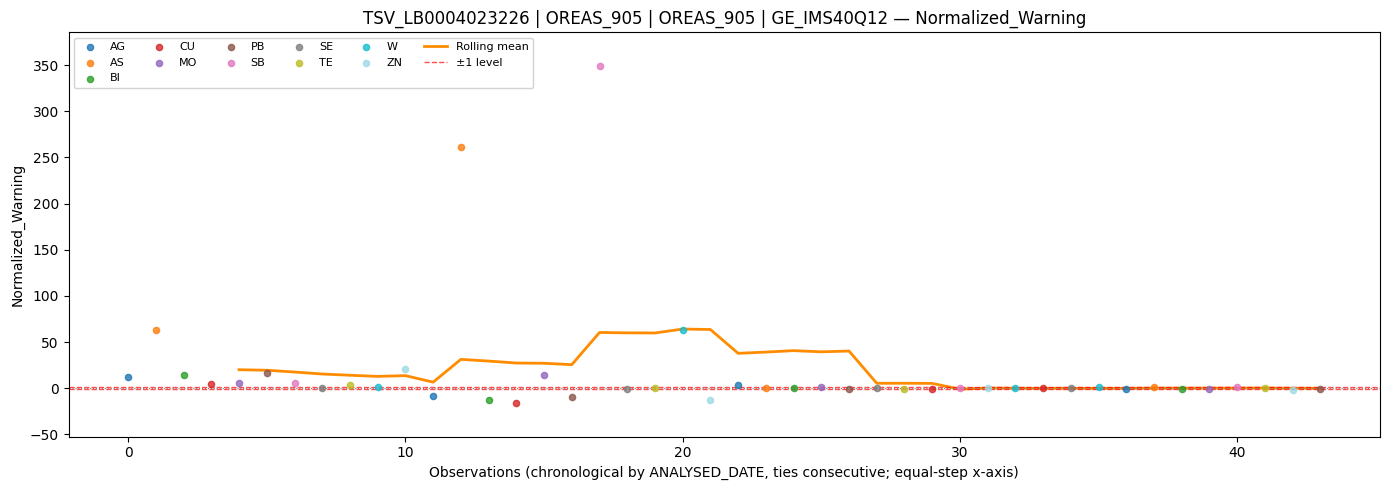

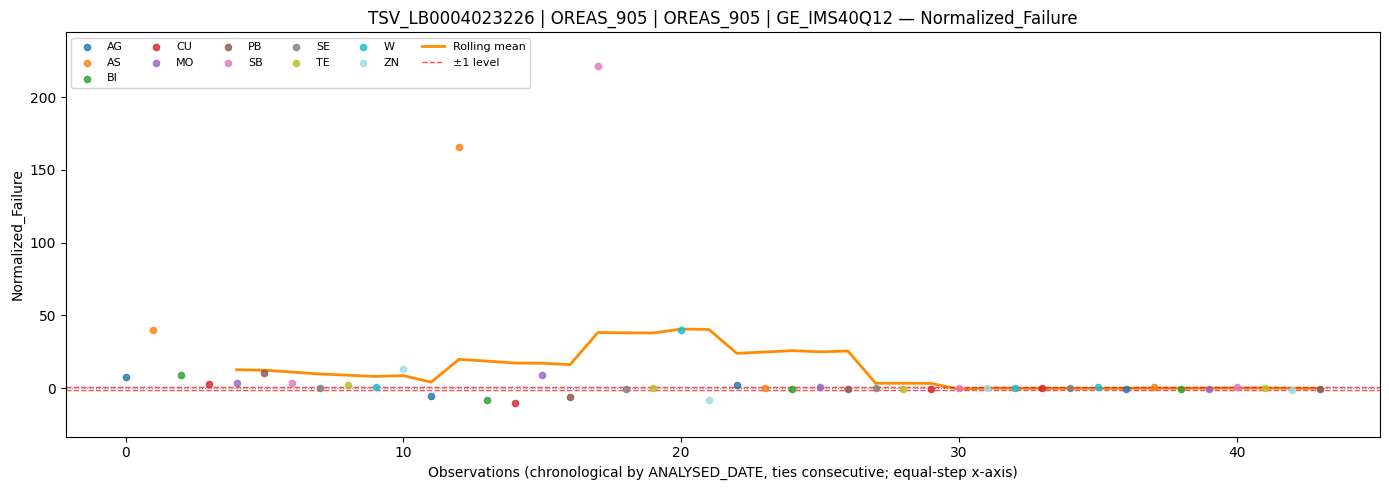

In [63]:
example = failure_drift_summary.iloc[0]

plot_group_drift(df_standard, example["JOB_CODE"], example["STD_CODE"],
                  example["STD_LOT_CODE"], example["SCHEME_CODE"],
                  value_col="Normalized_Warning", level=1.0)

plot_group_drift(df_standard, example["JOB_CODE"], example["STD_CODE"],
                  example["STD_LOT_CODE"], example["SCHEME_CODE"],
                  value_col="Normalized_Failure", level=1.0)